# Linear equations notebook

## Gaussian elimination

Consider a matrix equation of the form:

$$
\begin{pmatrix}
2 & 1 & 4 & 1 \\
3 & 4 & -1 & -1 \\
1 & -4 & 1 & 5 \\
2 & -2 & 1 & 3 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-4 \\
3 \\
9 \\
7
\end{pmatrix}
$$

To reduce the matrix, we are allowed two kinds of operation. It helps to think of this system as a collection of algebraic equations.

- You can multiply any row by a constant on *both* sides of the equal side. This leaves the equation the same.
- You can create linear combinations of different rows that maintain the equality.

Here, apply the following steps:

1. Divide the top row by the top left number:

$$
\begin{pmatrix}
1 & 0.5 & 2 & 0.5 \\
3 & 4 & -1 & -1 \\
1 & -4 & 1 & 5 \\
2 & -2 & 1 & 3 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-2 \\
3 \\
9 \\
7
\end{pmatrix}
$$

2. Subtract 3 times the top row from the second one:

$$
\begin{pmatrix}
1 & 0.5 & 2 & 0.5 \\
0 & 2.5 & -7 & -2.5 \\
1 & -4 & 1 & 5 \\
2 & -2 & 1 & 3 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-2 \\
9 \\
9 \\
7
\end{pmatrix}
$$

3. Subtract the top row from the third and 2 times the top row from the fourth.

$$
\begin{pmatrix}
1 & 0.5 & 2 & 0.5 \\
0 & 2.5 & -7 & -2.5 \\
0 & -4.5 & -1 & 4.5 \\
0 & -3 & -3 & 2 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-2 \\
9 \\
11 \\
11
\end{pmatrix}
$$

4. Divide the second row by 2.5:

$$
\begin{pmatrix}
1 & 0.5 & 2 & 0.5 \\
0 & 1 & -2.8 & -1 \\
0 & -4.5 & -1 & 4.5 \\
0 & -3 & -3 & 2 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-2 \\
3.6 \\
11 \\
11
\end{pmatrix}
$$

5. Add 4.5 times row 2 to row 3 and 3 times row 2 to row 4:

$$
\begin{pmatrix}
1 & 0.5 & 2 & 0.5 \\
0 & 1 & -2.8 & -1 \\
0 & 0 & -13.6 & 0 \\
0 & 0 & -11.4 & -1 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-2 \\
3.6 \\
27.2 \\
21.8
\end{pmatrix}
$$

6. Repeat:

$$
\begin{pmatrix}
1 & 0.5 & 2 & 0.5 \\
0 & 1 & -2.8 & -1 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-2 \\
3.6 \\
-2 \\
1
\end{pmatrix}
$$

We can now use backsubstitution to solve for $w$, $x$, $y$, and $z$.

## Backsubstitution

We can rewrite the matrix equation above in more general terms:

$$
\begin{pmatrix}
1 & a_{01} & a_{02} & a_{03} \\
0 & 1 & a_{12} & a_{13} \\
0 & 0 & 1 & a_{23} \\
0 & 0 & 0 & 1 
\end{pmatrix}
\begin{pmatrix}
x_0 \\
x_1 \\
x_2 \\
x_3
\end{pmatrix}
=
\begin{pmatrix}
v_0 \\
v_1 \\
v_2 \\
v_3
\end{pmatrix}
$$

We can solve for $\vec{x}$ starting from the last value and working backwards:

$$
\boxed{x_3 = v_3}
$$

$$
x_2 + a_{23}x_3 = v_2 \rightarrow \boxed{x_2 = v_2 - a_{23}x_3}
$$

$$
x_1 + a_{12}x_2 + a_{13}x_3 = v_1 \rightarrow \boxed{x_1 = v_1 - a_{12}x_2 - a_{13}x_3}
$$

and

$$
x_0 + a_{01}x_1 + a_{02}x_2 + a_{03}x_3 = v_0 \rightarrow \boxed{x_0 = v_0 - a_{01}x_1 - a_{02}x_2 - a_{03}x_3}
$$

In [4]:
# Example 6.1
import numpy as np 

# Set up matrix and vector for Ax=v
A = np.array([[2, 1, 4, 1],[3, 4, -1, -1],[1, -4, 1, 5], [2, -2, 1, 3]], dtype='float')
v = np.array([-4.0, 3.0, 9.0, 7.0], dtype = 'float')
N = v.size

# Gaussian elimination
for i in range(N):
    # Divide row by diagonal element
    div = A[i,i]
    A[i,:] /= div
    v[i] /= div

    # Subtract from lower rows
    for j in range(i+1,N):
        mult = A[j,i]
        A[j,:] -= mult*A[i,:]
        v[j] -= mult*v[i]

# Backsubstitution
x = np.empty(N, dtype="float")
for i in range(N-1,-1,-1):
    x[i] = v[i]
    for j in range(i+1,N):
        x[i] -= A[i,j]*x[j]

print(x)


[ 2. -1. -2.  1.]


You can check by hand that this is the correct answer. 

## Pivoting

The method breaks if one of the diagonal elements is 0. Consider:

$$
\begin{pmatrix}
0 & 9 & 2 & -9 \\
3 & 4 & -1 & -1 \\
1 & -4 & 1 & 5 \\
2 & -2 & 1 & 3 
\end{pmatrix}
\begin{pmatrix}
w \\
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
-22 \\
3 \\
9 \\
7
\end{pmatrix}
$$

The first row is a problem since $A_{0,0} = 0$. The matrix ${bf A}$ and vector $\vec{v}$ were obtained by subtracting 2 times row 2 from row 0. This is an allowed manipulation that does not change the solution. 

And yet, if we try our method above, we get:


In [ ]:
# Set up matrix and vector for Ax=v
A = np.array([[0, 9, 2, -9],[3, 4, -1, -1],[1, -4, 1, 5], [2, -2, 1, 3]], dtype='float')
v = np.array([-22.0, 3.0, 9.0, 7.0], dtype = 'float')
N = v.size

# Gaussian elimination
for i in range(N):
    # Divide row by diagonal element
    div = A[i,i]
    A[i,:] /= div
    v[i] /= div

    # Subtract from lower rows
    for j in range(i+1,N):
        mult = A[j,i]
        A[j,:] -= mult*A[i,:]
        v[j] -= mult*v[i]

# Backsubstitution
x = np.empty(N, dtype="float")
for i in range(N-1,-1,-1):
    x[i] = v[i]
    for j in range(i+1,N):
        x[i] -= A[i,j]*x[j]

print(x)


[nan nan nan nan]


/tmp/ipykernel_365623/1507252156.py:10: RuntimeWarning: divide by zero encountered in divide
  A[i,:] /= div
/tmp/ipykernel_365623/1507252156.py:10: RuntimeWarning: invalid value encountered in divide
  A[i,:] /= div
/tmp/ipykernel_365623/1507252156.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  v[i] /= div
/tmp/ipykernel_365623/1507252156.py:11: RuntimeWarning: invalid value encountered in scalar divide
  v[i] /= div


The issue is NOT that there is no solution. 

Problems with Gaussian elimination can be obvious from the beginning.

Or they can arise when a diagonal 0 gets computed during the algorithm.

Pivoting allows us to overcome these issues by moving the rows around. Here, let's swap row 0 with row 1.

In [7]:
# Set up matrix and vector for Ax=v
A = np.array([[3, 4, -1, -1],[0, 9, 2, -9],[1, -4, 1, 5], [2, -2, 1, 3]], dtype='float')
v = np.array([3.0, -22.0, 9.0, 7.0], dtype = 'float')
N = v.size

# Gaussian elimination
for i in range(N):
    # Divide row by diagonal element
    div = A[i,i]
    A[i,:] /= div
    v[i] /= div

    # Subtract from lower rows
    for j in range(i+1,N):
        mult = A[j,i]
        A[j,:] -= mult*A[i,:]
        v[j] -= mult*v[i]

# Backsubstitution
x = np.empty(N, dtype="float")
for i in range(N-1,-1,-1):
    x[i] = v[i]
    for j in range(i+1,N):
        x[i] -= A[i,j]*x[j]

print(x)


[ 2. -1. -2.  1.]


We get the same solution.

## LU decomposition

Consider the example of a 3x3 matrix:

$$
\begin{pmatrix}
a_{00} & a_{01} & a_{02} \\
a_{10} & a_{11} & a_{12} \\
a_{20} & a_{21} & a_{22}
\end{pmatrix}
= 
\begin{pmatrix}
l_{00} & 0 & 0 \\
l_{10} & l_{11} & 0 \\
l_{20} & l_{21} & l_{22}
\end{pmatrix}
\begin{pmatrix}
u_{00} & u_{01} & u_{02} \\
0 & u_{11} & u_{12} \\
0 & 0 & u_{22}
\end{pmatrix}
$$

The problem **A**$\vec{x}$ = $\vec{v}$ can be written as:

$$
\begin{pmatrix}
l_{00} & 0 & 0 \\
l_{10} & l_{11} & 0 \\
l_{20} & l_{21} & l_{22}
\end{pmatrix}
\begin{pmatrix}
u_{00} & u_{01} & u_{02} \\
0 & u_{11} & u_{12} \\
0 & 0 & u_{22}
\end{pmatrix}
\begin{pmatrix}
x_0 \\ x_1 \\ x_2 
\end{pmatrix}
= 
\begin{pmatrix}
v_0 \\ v_1 \\ v_2 
\end{pmatrix}
$$

Using:

$$
\begin{pmatrix}
u_{00} & u_{01} & u_{02} \\
0 & u_{11} & u_{12} \\
0 & 0 & u_{22}
\end{pmatrix}
\begin{pmatrix}
x_0 \\ x_1 \\ x_2 
\end{pmatrix}
= 
\begin{pmatrix}
y_0 \\ y_1 \\ y_2 
\end{pmatrix}
$$

we can solve for

$$
\begin{pmatrix}
l_{00} & 0 & 0 \\
l_{10} & l_{11} & 0 \\
l_{20} & l_{21} & l_{22}
\end{pmatrix}
\begin{pmatrix}
y_0 \\ y_1 \\ y_2 
\end{pmatrix}
= 
\begin{pmatrix}
v_0 \\ v_1 \\ v_2 
\end{pmatrix}
$$

The solution for $\vec{y}$ can be easily computed line-by-line similar to backstitution. Then, we can use backsubstitution to find the solution for $\vec{x}$ using $\vec{y}$. 

While it is possible to do this "by hand", there are useful numpy and scipy functions that does it for you, as shown below:

In [17]:
import time
import scipy.linalg as sla

N = 10000

# Create the matrix and Array randomly
rng = np.random.default_rng()
A = rng.random((N, N))
A += N * np.eye(N)          #Add to the diagonal to prevent issues
x_true = rng.random(N)
b = A @ x_true

# Test and time the numpy method
start = time.time()
x_np = np.linalg.solve(A, b)
stop = time.time()
print(f"The Numpy method for a {N}x{N} matrix took {stop-start:.4e} seconds.")

# Test and time the scipy method
start = time.time()
lu, piv = sla.lu_factor(A)
x = sla.lu_solve((lu, piv), b)
stop = time.time()
print(f"The Scipy method for a {N}x{N} matrix took {stop-start:.4e} seconds.")

start = time.time()
x = sla.lu_solve((lu, piv), b)
stop = time.time()
print(f"The Scipy method for a {N}x{N} matrix took {stop-start:.4e} seconds after the initial calculation of lu and piv.")



The Numpy method for a 10000x10000 matrix took 2.7080e+00 seconds.
The Scipy method for a 10000x10000 matrix took 3.2288e+00 seconds.
The Scipy method for a 10000x10000 matrix took 2.4803e-02 seconds after the initial calculation of lu and piv.


The scipy method takes time to calculate the lower diagonal, upper diagonal, and pivot matrices. After that, it is quite fast.

## Sparse matrices

First, let's consider the time complexity of the LUP decomposition library from scipy.

Looking at online references, we expect $O(N^3)$. 

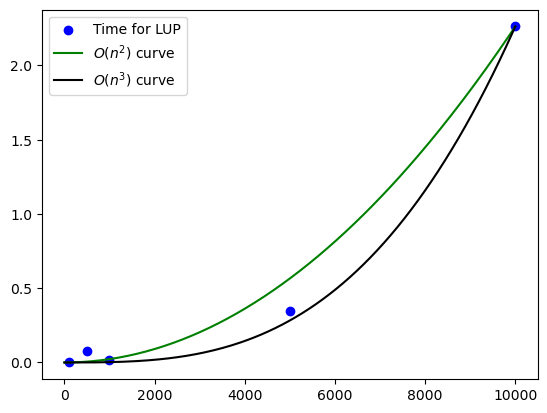

In [39]:
import matplotlib.pyplot as plt 
N = np.array([100, 500, 1000, 5000, 10000])
t = np.zeros(N.size)

for i, n in enumerate(N):
    # Create the matrix and Array randomly
    rng = np.random.default_rng()
    A = rng.random((n, n))
    A += n * np.eye(n)          #Add to the diagonal to prevent issues
    x_true = rng.random(n)
    b = A @ x_true

    start = time.time()
    lu, piv = sla.lu_factor(A)
    stop = time.time()

    t[i] = stop-start

N_plot = np.linspace(0, N[-1], num=200)
def t_plot_2(n):
    return  t[-1]/N[-1]**2*n**2
def t_plot_3(n):
    return  t[-1]/N[-1]**3*n**3

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(N, t, color='b', label="Time for LUP")
ax.plot(N_plot, t_plot_2(N_plot),'g', label="$O(n^2)$ curve")
ax.plot(N_plot, t_plot_3(N_plot),'k', label="$O(n^3)$ curve")
ax.legend(loc='upper left')

If instead of a full matrix, we had a 3-banded matrix to decompose of the form:

$$
A = 
\begin{pmatrix}
a_{00} & a_{01} & 0 & 0 & 0 & 0 & \ldots \\
a_{10} & a_{11} & a_{12} & 0 & 0 & 0 & \ldots\\
0 & a_{21} & a_{22} & a_{23} & 0 & 0 & \ldots\\
0 & 0 & a_{32} & a_{33} & a_{34} & 0 & \ldots\\
0 & 0 & 0 & a_{43} & a_{44} & a_{45} & \ldots\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \ddots 
\end{pmatrix}
$$

We will check the timing for the scipy sparse matrix functions.

/tmp/ipykernel_365623/1850857560.py:16: SparseEfficiencyWarning: splu converted its input to CSC format
  lup = ssp.linalg.splu(A)


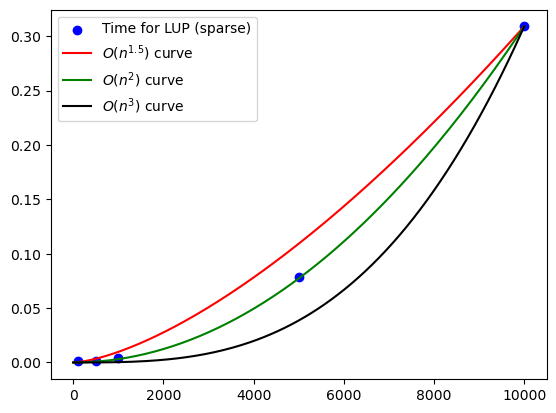

In [38]:
import scipy.sparse as ssp 

t_sparse = np.zeros(N.size)

for i, n in enumerate(N):
    # Create the matrix and Array randomly
    rng = np.random.default_rng()
    A_m = rng.random(n-1)   # Lower diagonal
    A_d = rng.random(n) + n # Main diagonal
    A_p = rng.random(n-1)   # Upper diagonal
    A = ssp.diags_array([A_m, A_d, A_p], offsets=[-1, 0, 1]).toarray()
    x_true = rng.random(n)
    b = A @ x_true

    start = time.time()
    lup = ssp.linalg.splu(A)
    stop = time.time()
    t_sparse[i] = stop - start 


def t_plot_1p5(n):
    return  t_sparse[-1]/N[-1]**1.5*n**1.5

def t_plot_2(n):
    return  t_sparse[-1]/N[-1]**2*n**2

def t_plot_3(n):
    return  t_sparse[-1]/N[-1]**3*n**3


fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(N, t_sparse, color='b', label="Time for LUP (sparse)")
ax.plot(N_plot, t_plot_1p5(N_plot), color='r', label="$O(n^{1.5})$ curve")
ax.plot(N_plot, t_plot_2(N_plot), color='g', label="$O(n^2)$ curve")
ax.plot(N_plot, t_plot_3(N_plot), color='k', label="$O(n^3)$ curve")
ax.legend(loc='upper left')

Sparse matrices grow slower in complexity.